1. Импортируем необходимые библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Настройка отображения графиков
%matplotlib inline
sns.set_style("whitegrid")

2. Загрузка данных

In [3]:
df = pd.read_csv('x13.csv')
print("=== 2. Первичный просмотр данных ===")
print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика:")
print(df.describe())

=== 2. Первичный просмотр данных ===
Размер данных: (18, 7)

Первые 5 строк:
   Number  Year  One  InternationalProduction  Stock  DomesticConsumption  \
0       1  1949    1                    149.3    4.2                108.1   
1       2  1950    1                    161.2    4.1                114.8   
2       3  1951    1                    171.5    3.1                123.2   
3       4  1952    1                    175.5    3.1                126.9   
4       5  1953    1                    180.8    1.1                132.1   

   Imports  
0     15.9  
1     16.4  
2     19.0  
3     19.1  
4     18.8  

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number                   18 non-null     int64  
 1   Year                     18 non-null     int64  
 2   One                      18 non-null     int64  

3. Разведочный анализ данных (EDA) и визуализация

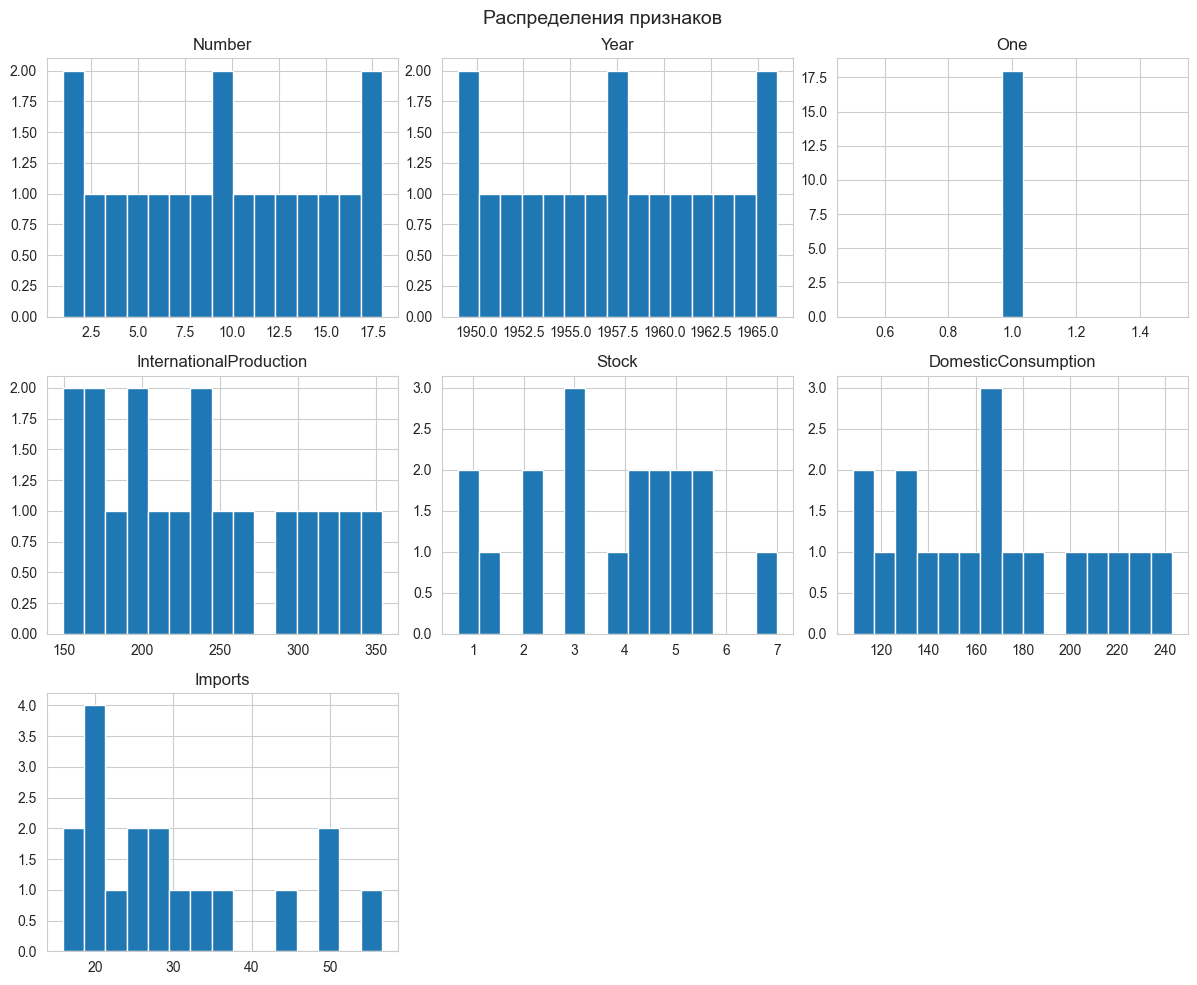

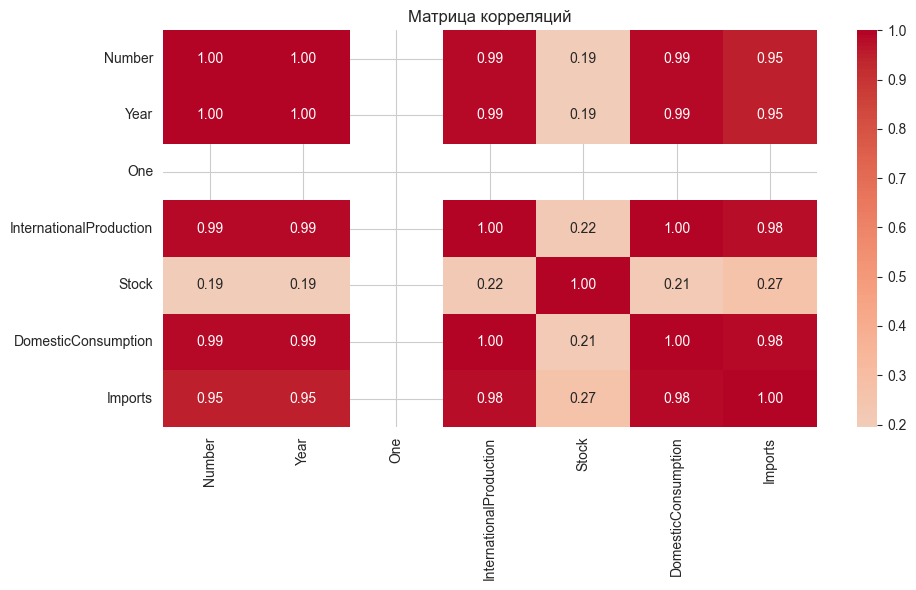


Целевая переменная: DomesticConsumption
Признаки: ['InternationalProduction', 'Stock', 'Imports']


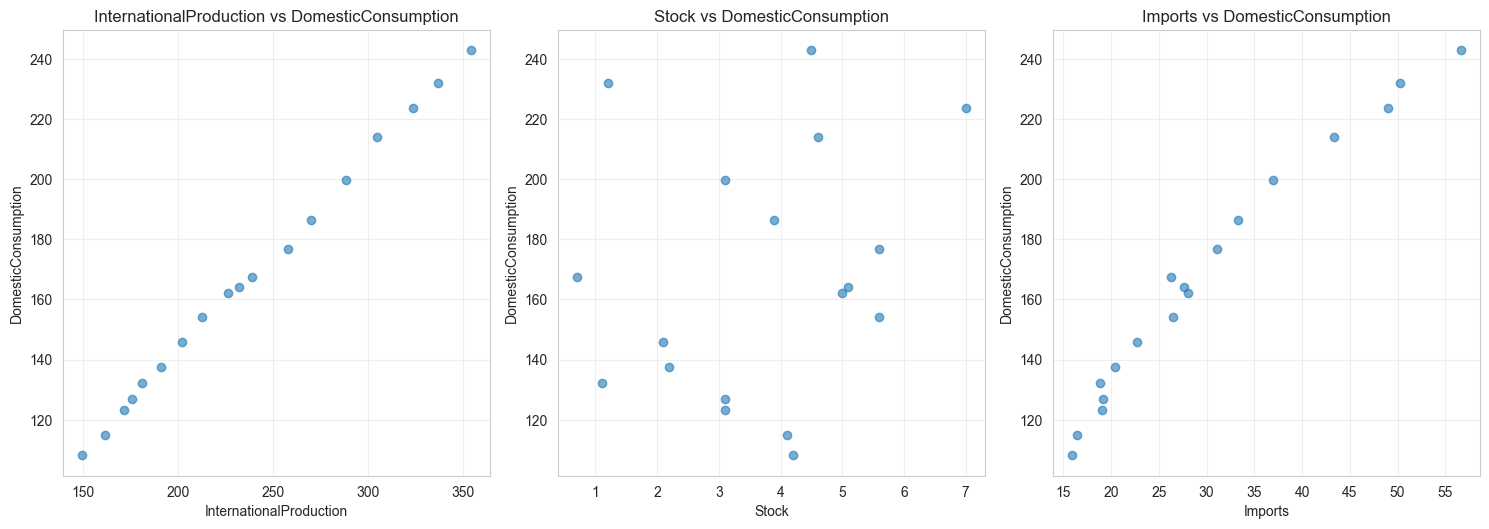

In [ ]:
# Гистограммы распределений
df.hist(figsize=(12, 10), bins=15)
plt.suptitle('Распределения признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

# Диаграммы рассеяния (признаки vs целевая переменная)
target_col = 'DomesticConsumption'
feature_cols = [col for col in df.columns if col not in ['Number', 'Year', 'One', target_col]]

print(f"\nЦелевая переменная: {target_col}")
print(f"Признаки: {feature_cols}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    if i < len(axes):
        axes[i].scatter(df[feature], df[target_col], alpha=0.6)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{feature} vs {target_col}')
        axes[i].grid(True, alpha=0.3)

# Удаляем лишние подграфики
for i in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

4. Выводы о влиянии признаков

In [5]:
corr_with_target = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)
print(f"Корреляция с {target_col}:")
print(corr_with_target)

print("\nНаблюдения:")
for feature, corr in corr_with_target.items():
    if corr > 0.5:
        print(f"  - {feature}: сильная положительная корреляция ({corr:.3f})")
    elif corr < -0.5:
        print(f"  - {feature}: сильная отрицательная корреляция ({corr:.3f})")
    elif abs(corr) > 0.3:
        print(f"  - {feature}: умеренная корреляция ({corr:.3f})")
    else:
        print(f"  - {feature}: слабая корреляция ({corr:.3f})")

Корреляция с DomesticConsumption:
InternationalProduction    0.998933
Number                     0.988633
Year                       0.988633
Imports                    0.984765
Stock                      0.213690
One                             NaN
Name: DomesticConsumption, dtype: float64

Наблюдения:
  - InternationalProduction: сильная положительная корреляция (0.999)
  - Number: сильная положительная корреляция (0.989)
  - Year: сильная положительная корреляция (0.989)
  - Imports: сильная положительная корреляция (0.985)
  - Stock: слабая корреляция (0.214)
  - One: слабая корреляция (nan)


5. Предобработка данных

In [6]:
# Удаление слабо коррелирующих признаков (|corr| < 0.1)
weak_features = corr_with_target[abs(corr_with_target) < 0.1].index.tolist()
print(f"Удаляемые признаки (слабая корреляция): {weak_features}")

# Формирование обработанного датафрейма
df_processed = df.drop(columns=weak_features + ['Number', 'Year', 'One'], errors='ignore')
print(f"Признаки после удаления: {[col for col in df_processed.columns if col != target_col]}")

# Нормализация данных
scaler = StandardScaler()
features_to_scale = [col for col in df_processed.columns if col != target_col]
df_scaled = df_processed.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_processed[features_to_scale])

print(f"Размер после предобработки: {df_scaled.shape}")
print("Первые 5 строк после нормализации:")
print(df_scaled.head())

Удаляемые признаки (слабая корреляция): []
Признаки после удаления: ['InternationalProduction', 'Stock', 'Imports']
Размер после предобработки: (18, 4)
Первые 5 строк после нормализации:
   InternationalProduction     Stock  DomesticConsumption   Imports
0                -1.429138  0.308583                108.1 -1.168853
1                -1.236354  0.249493                114.8 -1.127632
2                -1.069491 -0.341411                123.2 -0.913281
3                -1.004690 -0.341411                126.9 -0.905037
4                -0.918828 -1.523220                132.1 -0.929769


6. Разбиение на обучающую и тестовую выборки

In [7]:
X = df_scaled.drop(columns=[target_col])
y = df_scaled[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (14, 3)
Тестовая выборка: (4, 3)


7. Обучение модели линейной регрессии

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Коэффициенты: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")


Коэффициенты: [35.50515821 -0.1529838   4.45104485]
Intercept: 167.6568


8. Оценка корректности модели


Обучающая выборка:
  MSE:  2.5618
  RMSE: 1.6006
  MAE:  1.2823
  R²:   0.9983

Тестовая выборка:
  MSE:  8.0792
  RMSE: 2.8424
  MAE:  2.4782
  R²:   0.9822


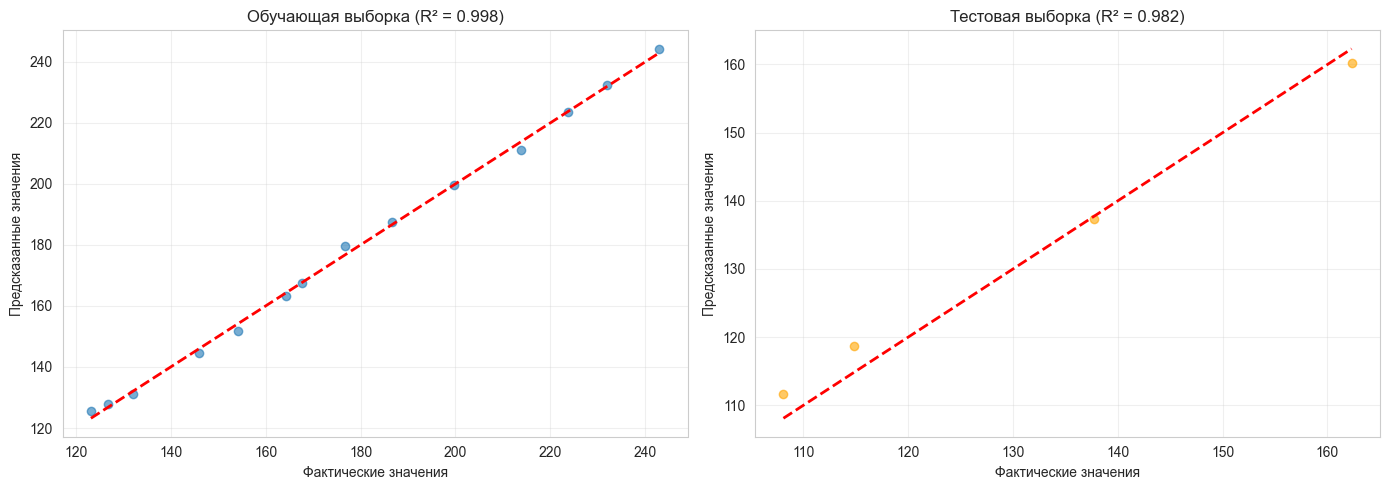

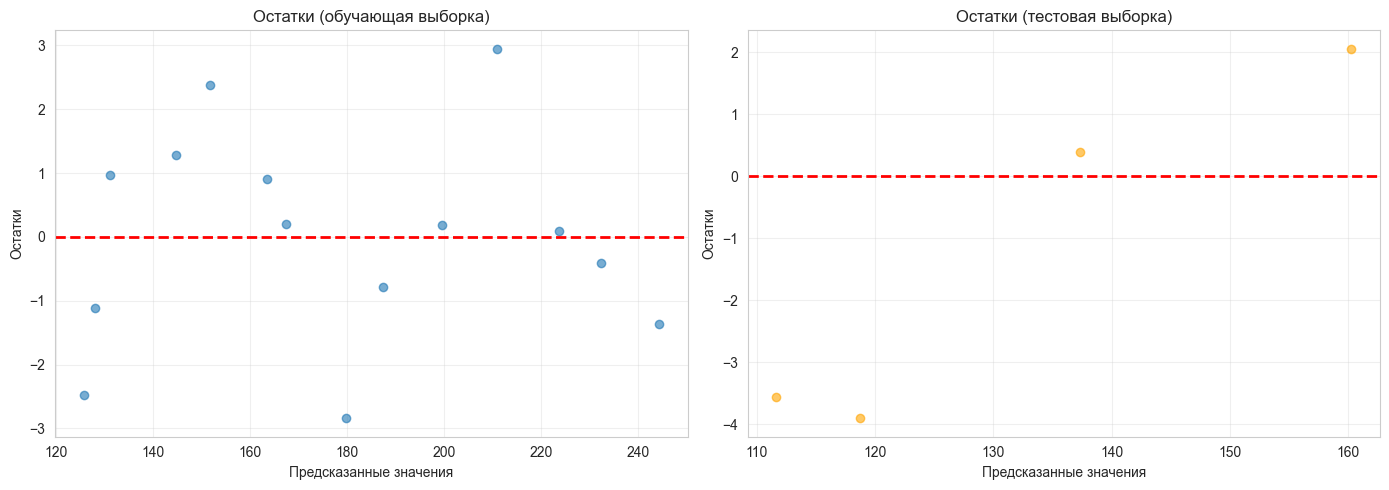


=== Итоговое уравнение регрессии ===
DomesticConsumption = 167.6568 + (35.5052) * InternationalProduction + (-0.1530) * Stock + (4.4510) * Imports


In [12]:
# Предсказания
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Метрики
train_metrics = evaluate_model(y_train, y_train_pred, "Обучающая выборка")
test_metrics = evaluate_model(y_test, y_test_pred, "Тестовая выборка")

# Визуализация: Предсказанные vs Фактические
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обучающая выборка
axes[0].scatter(y_train, y_train_pred, alpha=0.6)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'Обучающая выборка (R² = {train_metrics[3]:.3f})')
axes[0].grid(True, alpha=0.3)

# Тестовая выборка
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title(f'Тестовая выборка (R² = {test_metrics[3]:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Визуализация остатков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обучающая выборка
residuals_train = y_train - y_train_pred
axes[0].scatter(y_train_pred, residuals_train, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Остатки')
axes[0].set_title('Остатки (обучающая выборка)')
axes[0].grid(True, alpha=0.3)

# Тестовая выборка
residuals_test = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals_test, alpha=0.6, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Остатки (тестовая выборка)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Итоговое уравнение регрессии ===")
equation = f"{target_col} = {model.intercept_:.4f}"
for feat, coef in zip(X.columns, model.coef_):
    equation += f" + ({coef:.4f}) * {feat}"
print(equation)